DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised machine learning algorithm used for clustering data based on density rather than distance or predefined cluster counts.

It groups together points that are closely packed (high density) and labels points in low-density regions as noise (outliers).

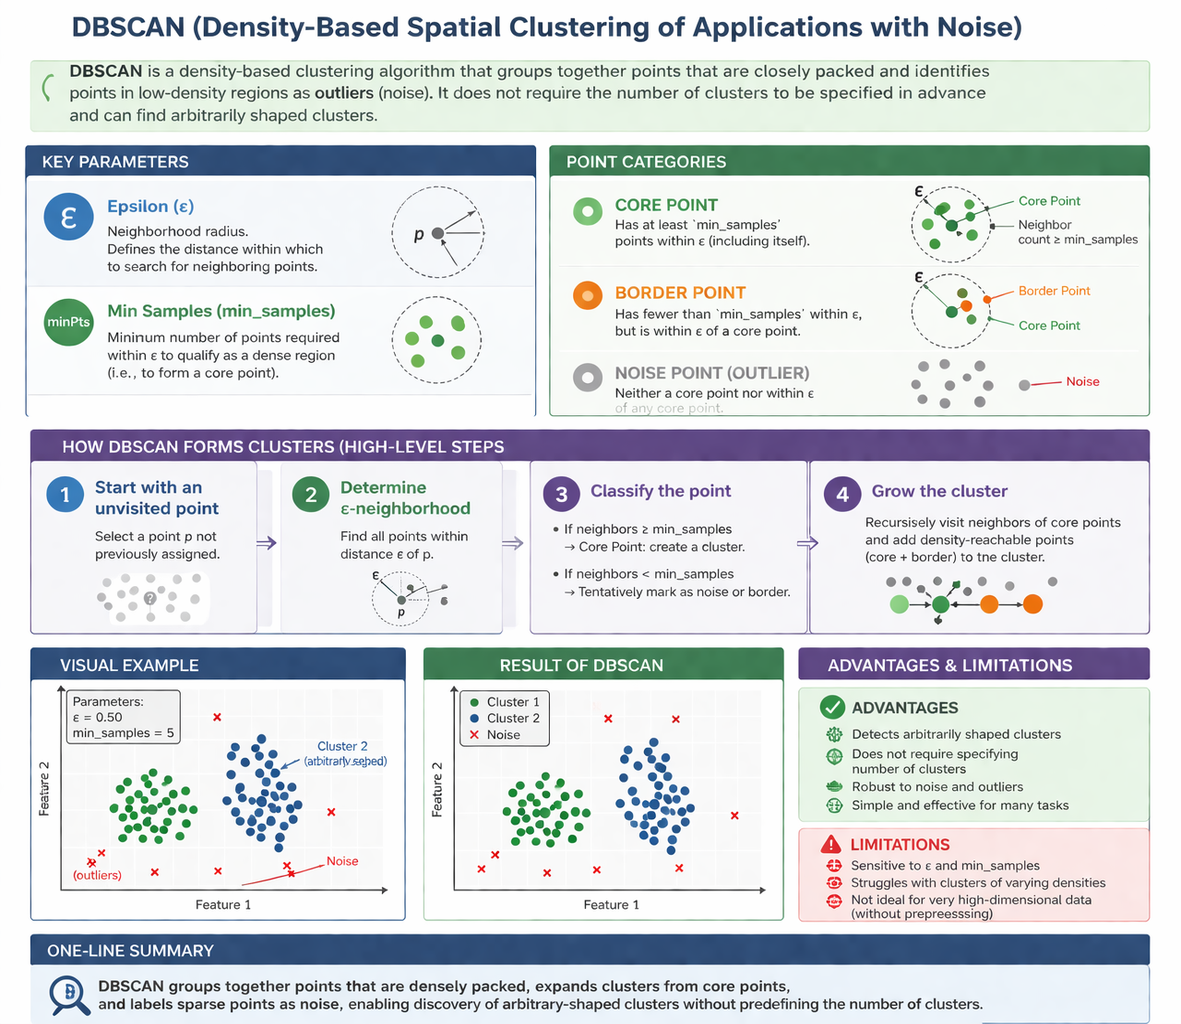

Key Characteristics of DBSCAN

* Density-Based Clustering

  Groups data points based on dense regions rather than distance to centroids.

* No Need to Specify Number of Clusters

  Automatically determines the number of clusters from the data.

* Handles Arbitrary-Shaped Clusters

  Can identify clusters of irregular shapes (unlike K-Means).

* Detects Noise and Outliers

  Points in low-density regions are labeled as noise.

* Core, Border, and Noise Points

  Classifies points into three types based on density conditions.

* Requires Two Parameters

  ε (epsilon): neighborhood radius

  min_samples: minimum points to form a cluster

* Robust to Noise

  Performs well even when the dataset contains outliers.

* Sensitive to Parameter Selection

  Results depend heavily on proper choice of ε and min_samples.

* Struggles with Varying Density

  Less effective when clusters have significantly different densities.

👉 One-line summary:
DBSCAN clusters data by identifying dense regions and separating sparse points as noise without needing a predefined number of clusters.

DBSCAN Clustering on the Wine Dataset

Applying DBSCAN (Density-Based Spatial Clustering of Applications with Noise) to the Wine dataset provides a fundamentally different perspective compared to methods like K-Means and supervised classifiers. While K-Means groups data based on distances to predefined centroids and requires specifying the number of clusters in advance, DBSCAN instead identifies clusters by locating regions of high data density. This makes it particularly useful when the underlying structure of the data is unknown.

In this analysis, DBSCAN examines how closely wine samples are packed in the feature space (after preprocessing such as scaling). Using parameters like ε (epsilon) to define neighborhood radius and min_samples to define minimum density, the algorithm classifies points into core points (dense regions), border points (near dense regions), and noise (outliers). This allows DBSCAN to naturally detect clusters of arbitrary shapes and isolate unusual samples that do not belong to any cluster.

When applied to the Wine dataset, DBSCAN helps reveal whether the natural groupings of wines align with true class labels without forcing a fixed number of clusters. It also highlights any outliers or ambiguous samples that may not clearly belong to a specific wine category something K-Means cannot explicitly identify.

Comparing DBSCAN with K-Means and supervised learning models provides valuable insights:

K-Means → assumes spherical clusters and requires predefined cluster count

Supervised models → learn from labeled data and optimize prediction accuracy

DBSCAN → discovers structure purely from data density and identifies noise

Overall, this approach demonstrates how a density-based unsupervised method can complement other techniques by offering a more flexible and realistic view of the dataset’s structure, especially when clusters are not well-separated or when outliers are present.

In [ ]:
# Modules
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix

# Display settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid", context="notebook")

In [ ]:
wine = load_wine() #Loading Data

# Features and target
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

# Combine into one DataFrame for exploration
df = X.copy()
df["target"] = y

# Quick preview
print("Shape of dataset (rows, columns):", df.shape)
df.head()


Shape of dataset (rows, columns): (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


**Basic Data Exploration** involves an initial inspection of the dataset to ensure it is suitable for clustering. This includes examining the dataset shape (number of rows and columns), checking data types and non-null counts, identifying any missing values, and reviewing basic statistical summaries of numerical features. These steps confirm that all features are numeric—an essential requirement for DBSCAN and that there are no significant data quality issues, indicating that minimal preprocessing is needed before applying scaling and clustering techniques.

In [ ]:
print("Shape:", df.shape)

print("\nInfo:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

print("\nStatistical summary of features:")
df.describe().T

Shape: (178, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-nu

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


**Preprocessing** involves standardizing features to ensure fair distance calculations in DBSCAN, which relies on metrics like Euclidean distance. If features have different scales, those with larger ranges can disproportionately influence clustering results. To address this, StandardScaler is applied, transforming each feature to have a mean of 0 and a standard deviation of 1. This results in two representations: X, the original feature space, and X_scaled, the standardized feature space used for DBSCAN, ensuring balanced and accurate clustering.

In [ ]:
# Initialize and fit scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# For convenience, also keep as DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


**Principal Component Analysis (PCA)** is applied to reduce the high-dimensional Wine dataset (13 features) into two principal components for visualization purposes. This dimensionality reduction enables easier plotting and interpretation of cluster structures in a 2D space. It is important to note that PCA is used only for visualization, while DBSCAN is performed on the full standardized feature set to preserve clustering accuracy. A new DataFrame is created containing PC1 and PC2 (the two principal components), along with the target variable (true wine cultivar) to facilitate comparison between discovered clusters and actual class labels.

In [ ]:
# PCA to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["target"] = y

pca_df.head()

,PC1,PC2,target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


In [ ]:
# Hyper Parameters
eps_values = [1.8, 2.0, 2.2, 2.5, 3.0]
min_samples_values = [3, 5, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        unique_labels = set(labels)
        # Count clusters excluding noise (-1)
        n_clusters = len([lbl for lbl in unique_labels if lbl != -1])
        n_noise = list(labels).count(-1)

        # Compute silhouette only when there are at least 2 clusters
        if n_clusters >= 2:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = np.nan

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": sil
        })

results_df = pd.DataFrame(results)
results_df

,eps,min_samples,n_clusters,n_noise,silhouette
0,1.8,3,8,90,-0.032552
1,1.8,5,7,118,-0.175689
2,1.8,10,0,178,NaN
3,2.0,3,5,64,0.031407
4,2.0,5,5,85,-0.032906
5,2.0,10,1,139,NaN
6,2.2,3,3,44,-0.003857
7,2.2,5,2,55,0.142678
8,2.2,10,2,89,0.059227
9,2.5,3,1,23,NaN


In [ ]:
# Chosen parameters
eps_opt = 2.5
min_samples_opt = 10

dbscan = DBSCAN(eps=eps_opt, min_samples=min_samples_opt)
db_labels = dbscan.fit_predict(X_scaled)

# Add labels to DataFrame
df["dbscan_cluster"] = db_labels
pca_df["dbscan_cluster"] = db_labels

# Basic counts
unique_labels = sorted(set(db_labels))
n_clusters_opt = len([lbl for lbl in unique_labels if lbl != -1])
n_noise_opt = list(db_labels).count(-1)

print(f"Unique labels (including noise): {unique_labels}")
print(f"Number of clusters (excluding noise): {n_clusters_opt}")
print(f"Number of noise points: {n_noise_opt}")


Unique labels (including noise): [np.int64(-1), np.int64(0), np.int64(1)]
Number of clusters (excluding noise): 2
Number of noise points: 32


Although DBSCAN is an unsupervised algorithm, the availability of true cultivar labels in the Wine dataset allows for quantitative evaluation of clustering performance. This is done using the Adjusted Rand Index (ARI), which measures the similarity between the predicted clusters and true labels (with 1 indicating perfect alignment and values near 0 indicating random grouping), and a confusion matrix, which compares true classes against DBSCAN cluster labels (including noise labeled as -1). These metrics help assess how well DBSCAN captures the underlying structure of the data in relation to actual wine cultivars.

Adjusted Rand Index (DBSCAN vs true labels): 0.42354907037688627

Confusion Matrix (rows = true class, cols = [Noise, Cluster 0, Cluster 1, ...]):

[[ 0  0  0]
 [ 3 56  0]
 [25 45  1]]


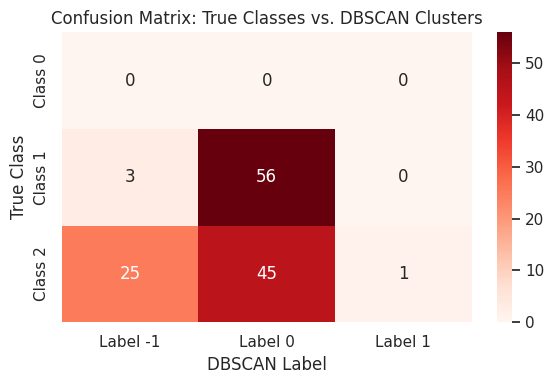


Silhouette score for final DBSCAN model: 0.20438854495188735


In [ ]:
# Adjusted Rand Index (handles label -1 naturally)
ari_dbscan = adjusted_rand_score(y, db_labels)
print("Adjusted Rand Index (DBSCAN vs true labels):", ari_dbscan)

# Confusion matrix: include noise label (-1) explicitly
cm_labels = [-1] + [lbl for lbl in unique_labels if lbl != -1]
cm = confusion_matrix(y, db_labels, labels=cm_labels)

print("\nConfusion Matrix (rows = true class, cols = [Noise, Cluster 0, Cluster 1, ...]):\n")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=[f"Label {lbl}" for lbl in cm_labels],
    yticklabels=[f"Class {c}" for c in sorted(y.unique())]
)
plt.xlabel("DBSCAN Label")
plt.ylabel("True Class")
plt.title("Confusion Matrix: True Classes vs. DBSCAN Clusters")
plt.tight_layout()
plt.show()

# Silhouette score for the chosen parameters (only if >= 2 clusters)
if n_clusters_opt >= 2:
    sil_opt = silhouette_score(X_scaled, db_labels)
else:
    sil_opt = np.nan

print("\nSilhouette score for final DBSCAN model:", sil_opt)

To interpret the clustering results, the standardized Wine dataset is projected into a 2D space using PCA and visualized through scatter plots. The plot displays both the true cultivar labels (for reference) and the DBSCAN cluster labels, including noise points. Noise points (labeled as -1) are highlighted distinctly, often in gray, while points belonging to the same cluster—whether core or border—share the same color. This visualization helps assess whether DBSCAN identifies dense regions that correspond to actual cultivars and reveals the position of noise points relative to the main clusters, providing insight into cluster quality and separation.

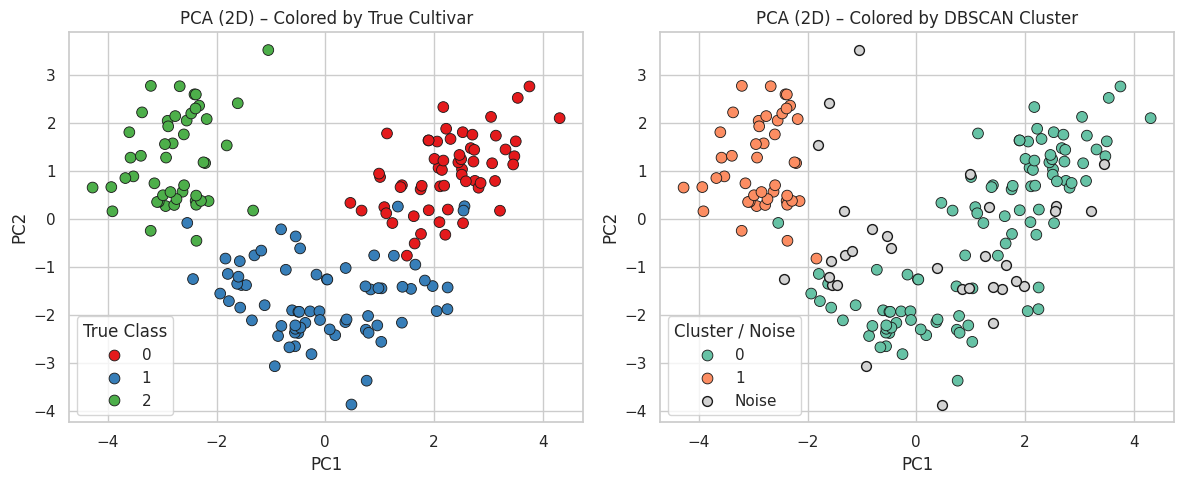

In [ ]:
plt.figure(figsize=(12, 5))

# Left: True labels in PCA space
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="target",
    palette="Set1",
    s=60,
    edgecolor="k"
)
plt.title("PCA (2D) – Colored by True Cultivar")
plt.legend(title="True Class")

# Right: DBSCAN labels in PCA space
plt.subplot(1, 2, 2)

# Separate noise and cluster points for nicer plotting
noise_mask = pca_df["dbscan_cluster"] == -1
cluster_mask = ~noise_mask

# Plot cluster points
sns.scatterplot(
    data=pca_df[cluster_mask],
    x="PC1",
    y="PC2",
    hue="dbscan_cluster",
    palette="Set2",
    s=60,
    edgecolor="k",
    legend="full"
)

# Overlay noise points in gray
plt.scatter(
    pca_df.loc[noise_mask, "PC1"],
    pca_df.loc[noise_mask, "PC2"],
    c="lightgray",
    s=50,
    edgecolors="k",
    label="Noise"
)

plt.title("PCA (2D) – Colored by DBSCAN Cluster")
plt.legend(title="Cluster / Noise")
plt.tight_layout()
plt.show()


Findings and Conclusion

The DBSCAN analysis, using eps = 2.5 and min_samples = 10, identified approximately two primary clusters along with a notable number of noise points (~30 out of 178 samples). The Adjusted Rand Index (≈ 0.42) indicates a moderate alignment between the discovered clusters and the true wine cultivars, suggesting that DBSCAN captures some meaningful structure but does not perfectly match the class labels due to overlap in feature space. Similarly, the silhouette score (≈ 0.20) reflects moderate cluster separation, consistent with the presence of overlapping regions. The identification of noise points highlights DBSCAN’s ability to detect ambiguous or low-density samples, providing additional insight beyond traditional clustering methods. Overall, DBSCAN offers a complementary perspective to K-Means by uncovering density-based groupings and outliers, revealing that while the dataset exhibits inherent cluster structure, it also contains significant overlap among cultivars.